In [1]:
import os
import cv2
import numpy as np
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
X = []
y = []
path = '/content/drive/MyDrive/image datazset'

In [3]:
for file in sorted(os.listdir(path)):
    if file.endswith('.jpg'):
        label = int(file.split('_')[1].split('.')[0])
        img = cv2.imread(os.path.join(path, file), cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (92, 112))
        X.append(img.flatten())
        y.append(label)

In [4]:
X = np.array(X)
y = np.array(y)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

In [6]:
pca = PCA(n_components=40)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

In [7]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_pca, y_train)
y_pred = knn.predict(X_test_pca)

In [8]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.67      0.67      0.67         3
           2       0.75      1.00      0.86         3
           3       0.67      0.67      0.67         3
           4       1.00      1.00      1.00         3
           5       0.50      0.67      0.57         3
           6       1.00      1.00      1.00         3
           7       0.75      1.00      0.86         3
           8       1.00      1.00      1.00         3
           9       0.75      1.00      0.86         3
          10       1.00      1.00      1.00         3
          11       1.00      1.00      1.00         3
          12       1.00      1.00      1.00         3
          13       1.00      1.00      1.00         3
          14       1.00      1.00      1.00         3
          15       1.00      1.00      1.00         3
          16       1.00      0.67      0.80         3
          17       1.00      0.67      0.80         3
          18       0.75    

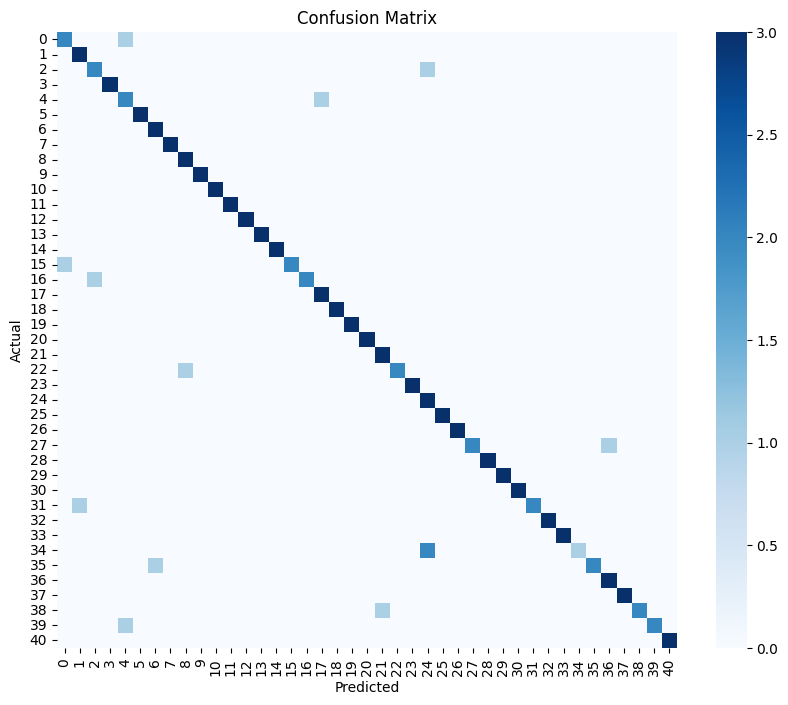

In [9]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=False, cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()